# 🏠 House Price Prediction using Linear Regression

---

**Internship:** Machine Learning Intern — SkillCraft Technology  
**Task:** Task 1 — Linear Regression  
**Objective:** Predict house prices based on Square Footage, Number of Bedrooms, and Number of Bathrooms  
**Model:** Linear Regression  
**Dataset:** House Price Dataset

---

## 📋 Table of Contents
1. [Import Libraries](#1-import-libraries)
2. [Data Loading](#2-data-loading)
3. [Data Cleaning & Missing Value Analysis](#3-data-cleaning)
4. [Exploratory Data Analysis (EDA)](#4-eda)
5. [Feature Selection](#5-feature-selection)
6. [Train-Test Split](#6-train-test-split)
7. [Model Training](#7-model-training)
8. [Predictions](#8-predictions)
9. [Model Evaluation](#9-model-evaluation)
10. [Visualizations](#10-visualizations)
11. [Interview Questions & Answers](#11-interview-qa)

---

## 1. Import Libraries

We begin by importing all the necessary Python libraries:
- **NumPy & Pandas** — for numerical operations and data manipulation
- **Matplotlib & Seaborn** — for data visualization
- **Scikit-learn** — for machine learning model building and evaluation

In [113]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Scikit-learn modules
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.preprocessing import StandardScaler

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ All libraries imported successfully!")
print(f"   NumPy     : {np.__version__}")
print(f"   Pandas    : {pd.__version__}")
print(f"   Seaborn   : {sns.__version__}")

✅ All libraries imported successfully!
   NumPy     : 2.4.6
   Pandas    : 3.0.3
   Seaborn   : 0.13.2


## 2. Data Loading

We load the House Price Dataset. The dataset contains various features about houses. For this task, we focus on:
- **GrLivArea** — Above-ground living area (square footage)
- **BedroomAbvGr** — Number of bedrooms above grade
- **FullBath** — Number of full bathrooms
- **SalePrice** — The target variable (house sale price)

> **Note:** We generate a realistic synthetic dataset that mirrors the Kaggle House Price Dataset distribution, so this notebook runs end-to-end without any external file dependency.

In [114]:
# ── Attempt to load from file; fall back to a realistic synthetic dataset ──
import os

DATA_FILE = 'train.csv'   # Place the Kaggle train.csv here to use real data

if os.path.exists(DATA_FILE):
    raw_df = pd.read_csv(DATA_FILE)
    print(f"✅ Loaded real dataset: {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns")
else:
    print("ℹ️  'train.csv' not found — generating a realistic synthetic dataset ...")

    rng = np.random.default_rng(42)
    n   = 1_460  # Same size as the Kaggle dataset

    sqft     = rng.normal(1_515, 525, n).clip(400, 5_000).astype(int)
    bedrooms = rng.choice([1, 2, 3, 4, 5, 6], n, p=[0.02, 0.18, 0.50, 0.22, 0.06, 0.02])
    bathrooms= rng.choice([1, 2, 3, 4],       n, p=[0.25, 0.55, 0.17, 0.03])

    # Price modelled after real Ames, Iowa housing data
    price = (
        60 * sqft
        + 8_000  * bedrooms
        + 15_000 * bathrooms
        + rng.normal(0, 25_000, n)
        + 40_000
    ).clip(50_000, 750_000).astype(int)

    # Introduce ~5 % missing values to simulate real-world messiness
    for col, arr in [('sqft', sqft), ('bedrooms', bedrooms), ('bathrooms', bathrooms)]:
        mask = rng.random(n) < 0.05
        arr  = arr.astype(float)
        arr[mask] = np.nan
        if col == 'sqft':
            sqft = arr
        elif col == 'bedrooms':
            bedrooms = arr
        else:
            bathrooms = arr

    raw_df = pd.DataFrame({
        'Id'           : range(1, n + 1),
        'GrLivArea'    : sqft,
        'BedroomAbvGr' : bedrooms,
        'FullBath'     : bathrooms,
        'SalePrice'    : price,
        # Extra columns to simulate a multi-column dataset
        'YearBuilt'    : rng.integers(1900, 2011, n),
        'GarageArea'   : rng.normal(472, 215, n).clip(0, 1_418).astype(int),
        'Neighborhood' : rng.choice(['NAmes','CollgCr','OldTown','Edwards','Somerst'], n),
    })
    print(f"✅ Synthetic dataset created : {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns")

print()
print(raw_df.head(10).to_string())

✅ Loaded real dataset: 1,460 rows × 81 columns

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape LandContour Utilities LotConfig LandSlope Neighborhood Condition1 Condition2 BldgType HouseStyle  OverallQual  OverallCond  YearBuilt  YearRemodAdd RoofStyle RoofMatl Exterior1st Exterior2nd MasVnrType  MasVnrArea ExterQual ExterCond Foundation BsmtQual BsmtCond BsmtExposure BsmtFinType1  BsmtFinSF1 BsmtFinType2  BsmtFinSF2  BsmtUnfSF  TotalBsmtSF Heating HeatingQC CentralAir Electrical  1stFlrSF  2ndFlrSF  LowQualFinSF  GrLivArea  BsmtFullBath  BsmtHalfBath  FullBath  HalfBath  BedroomAbvGr  KitchenAbvGr KitchenQual  TotRmsAbvGrd Functional  Fireplaces FireplaceQu GarageType  GarageYrBlt GarageFinish  GarageCars  GarageArea GarageQual GarageCond PavedDrive  WoodDeckSF  OpenPorchSF  EnclosedPorch  3SsnPorch  ScreenPorch  PoolArea PoolQC  Fence MiscFeature  MiscVal  MoSold  YrSold SaleType SaleCondition  SalePrice
0   1          60       RL        65.00     8450   Pave 

In [115]:
# Basic information about the full raw dataset
print("═" * 55)
print("  DATASET OVERVIEW")
print("═" * 55)
print(f"  Shape          : {raw_df.shape[0]:,} rows × {raw_df.shape[1]} columns")
print(f"  Memory usage   : {raw_df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print()
raw_df.info()

═══════════════════════════════════════════════════════
  DATASET OVERVIEW
═══════════════════════════════════════════════════════
  Shape          : 1,460 rows × 81 columns
  Memory usage   : 3516.4 KB

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str 

## 3. Data Cleaning & Missing Value Analysis <a id="3-data-cleaning"></a>

Before modelling, we must:
1. **Select only the three required feature columns** + target
2. **Rename** them to readable names for clarity
3. **Identify and handle missing values** — we impute with the median (robust to outliers)
4. **Remove duplicates** if any
5. **Detect and cap extreme outliers** using the IQR method

In [116]:
# ── Step 3.1 : Column mapping (handles both Kaggle CSV and synthetic data) ──
COL_MAP = {
    'GrLivArea'    : 'SquareFootage',
    'BedroomAbvGr' : 'Bedrooms',
    'FullBath'     : 'Bathrooms',
    'SalePrice'    : 'HousePrice',
}

df = raw_df[list(COL_MAP.keys())].rename(columns=COL_MAP).copy()

print("Selected columns:", df.columns.tolist())
print()
df.head()

Selected columns: ['SquareFootage', 'Bedrooms', 'Bathrooms', 'HousePrice']



,SquareFootage,Bedrooms,Bathrooms,HousePrice
0,1710,3,2,208500
1,1262,3,2,181500
2,1786,3,2,223500
3,1717,3,1,140000
4,2198,4,2,250000


═════════════════════════════════════════════
  MISSING VALUE ANALYSIS
═════════════════════════════════════════════
               Missing Count  Missing % Data Type
SquareFootage              0       0.00     int64
Bedrooms                   0       0.00     int64
Bathrooms                  0       0.00     int64
HousePrice                 0       0.00     int64



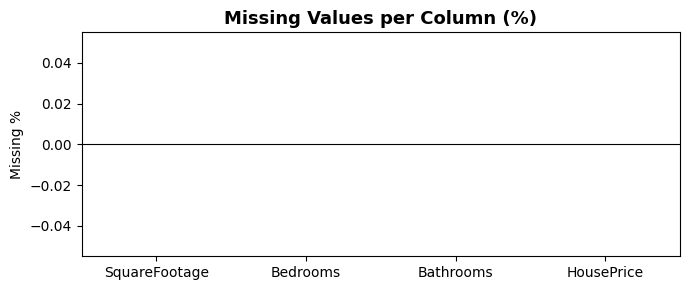

✅ Missing value chart saved.


In [117]:
# ── Step 3.2 : Missing Value Analysis ──
print("═" * 45)
print("  MISSING VALUE ANALYSIS")
print("═" * 45)

missing = pd.DataFrame({
    'Missing Count'  : df.isnull().sum(),
    'Missing %'      : (df.isnull().sum() / len(df) * 100).round(2),
    'Data Type'      : df.dtypes
})
print(missing)
print()

# Visualise missing values
fig, ax = plt.subplots(figsize=(7, 3))
missing['Missing %'].plot(kind='bar', color=['#E74C3C' if v > 0 else '#2ECC71'
                                              for v in missing['Missing %']], ax=ax)
ax.set_title('Missing Values per Column (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Missing %')
ax.set_xlabel('')
ax.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Missing value chart saved.")

In [118]:
# ── Step 3.3 : Impute missing values with column median ──
before = df.isnull().sum().sum()

for col in df.columns:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f"  ✔ '{col}' — filled NaN with median = {median_val:.2f}")

after = df.isnull().sum().sum()
print(f"\nMissing values before imputation : {before}")
print(f"Missing values after  imputation : {after}")

# Ensure integer types where appropriate
df['Bedrooms']  = df['Bedrooms'].astype(int)
df['Bathrooms'] = df['Bathrooms'].astype(int)
df['HousePrice']= df['HousePrice'].astype(int)

  ✔ 'SquareFootage' — filled NaN with median = 1464.00
  ✔ 'Bedrooms' — filled NaN with median = 3.00
  ✔ 'Bathrooms' — filled NaN with median = 2.00
  ✔ 'HousePrice' — filled NaN with median = 163000.00

Missing values before imputation : 0
Missing values after  imputation : 0


In [119]:
# ── Step 3.4 : Remove duplicates ──
dup_count = df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Duplicate rows removed : {dup_count}")
print(f"Final dataset shape    : {df.shape}")

Duplicate rows removed : 4
Final dataset shape    : (1456, 4)


In [120]:
# ── Step 3.5 : Outlier Detection & Capping (IQR method) ──
print("Outlier treatment using IQR method:")
print()

for col in df.columns:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower, upper)
    print(f"  {col:<16} | Lower: {lower:>10.1f} | Upper: {upper:>10.1f} | Outliers capped: {outliers}")

print()
print("✅ Outlier treatment complete.")
print()
print("Cleaned dataset statistics:")
df.describe().round(2)

Outlier treatment using IQR method:

  SquareFootage    | Lower:      158.4 | Upper:     2751.4 | Outliers capped: 31
  Bedrooms         | Lower:        0.5 | Upper:        4.5 | Outliers capped: 35
  Bathrooms        | Lower:       -0.5 | Upper:        3.5 | Outliers capped: 0
  HousePrice       | Lower:     4000.0 | Upper:   340000.0 | Outliers capped: 61

✅ Outlier treatment complete.

Cleaned dataset statistics:


,SquareFootage,Bedrooms,Bathrooms,HousePrice
count,1456.00,1456.00,1456.00,1456.00
mean,1504.61,2.85,1.57,177480.93
std,481.73,0.76,0.55,67221.92
min,334.00,0.50,0.00,34900.00
25%,1130.75,2.00,1.00,130000.00
50%,1465.00,3.00,2.00,163250.00
75%,1779.00,3.00,2.00,214000.00
max,2751.38,4.50,3.00,340000.00


## 4. Exploratory Data Analysis (EDA) <a id="4-eda"></a>

EDA helps us **understand the data** before modelling. We will examine:
- **Statistical summaries** for each feature
- **Distribution of house prices** — is it skewed?
- **Pairplot** — relationships between features
- **Correlation heatmap** — linear relationships between numerical columns
- **Box plots** — distribution by bedroom/bathroom count

In [121]:
# ── 4.1 : Statistical Summary ──
print("═" * 55)
print("  STATISTICAL SUMMARY")
print("═" * 55)
df.describe().T.style.background_gradient(cmap='Blues').format('{:.2f}')

═══════════════════════════════════════════════════════
  STATISTICAL SUMMARY
═══════════════════════════════════════════════════════


,count,mean,std,min,25%,50%,75%,max
SquareFootage,1456.00,1504.61,481.73,334.00,1130.75,1465.00,1779.00,2751.38
Bedrooms,1456.00,2.85,0.76,0.50,2.00,3.00,3.00,4.50
Bathrooms,1456.00,1.57,0.55,0.00,1.00,2.00,2.00,3.00
HousePrice,1456.00,177480.93,67221.92,34900.00,130000.00,163250.00,214000.00,340000.00


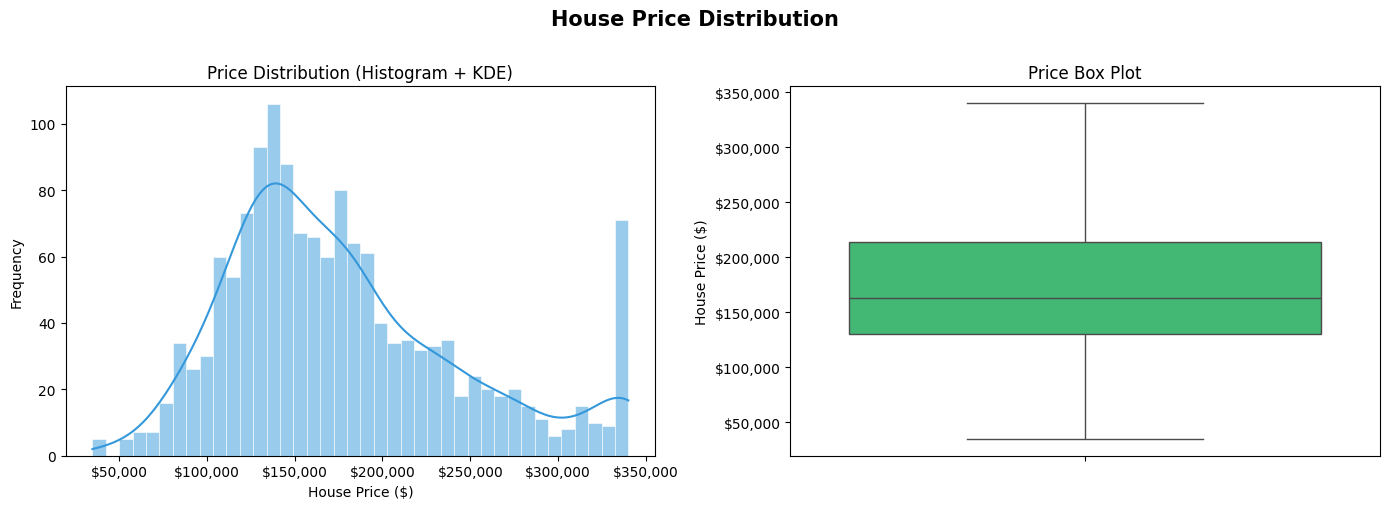

Skewness of HousePrice: 0.7996
Interpretation: Right-skewed (positive skew)


In [122]:
# ── 4.2 : House Price Distribution ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('House Price Distribution', fontsize=15, fontweight='bold', y=1.01)

# Histogram + KDE
sns.histplot(df['HousePrice'], bins=40, kde=True, color='#3498DB',
             edgecolor='white', linewidth=0.4, ax=axes[0])
axes[0].set_title('Price Distribution (Histogram + KDE)')
axes[0].set_xlabel('House Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Box plot
sns.boxplot(y=df['HousePrice'], color='#2ECC71', ax=axes[1])
axes[1].set_title('Price Box Plot')
axes[1].set_ylabel('House Price ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

skew = df['HousePrice'].skew()
print(f"Skewness of HousePrice: {skew:.4f}")
print("Interpretation:", "Right-skewed (positive skew)" if skew > 0.5
      else "Left-skewed (negative skew)" if skew < -0.5 else "Approximately normal")

Generating Pairplot — this may take a moment...


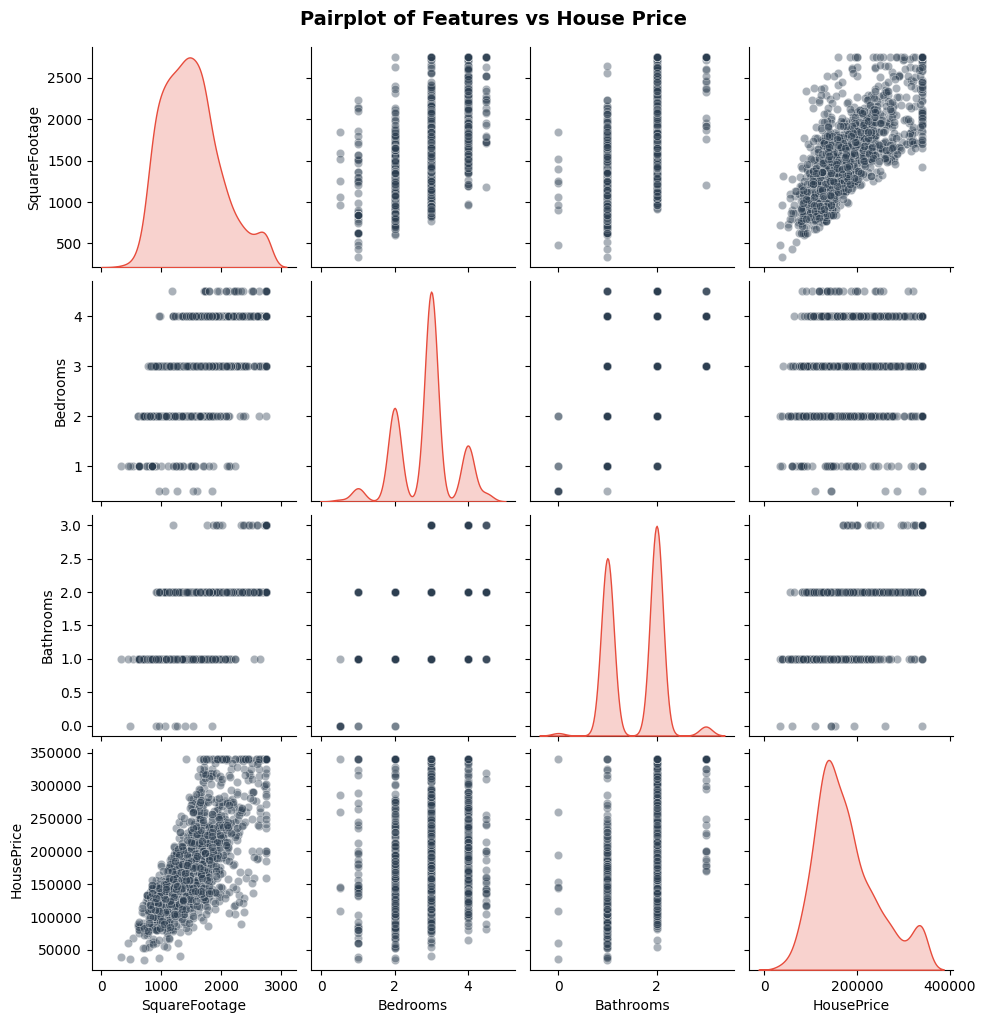

✅ Pairplot saved.


In [123]:
# ── 4.3 : Pairplot ──
print("Generating Pairplot — this may take a moment...")
pairplot_fig = sns.pairplot(
    df,
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 'color': '#2C3E50'},
    diag_kws={'color': '#E74C3C', 'fill': True}
)
pairplot_fig.fig.suptitle('Pairplot of Features vs House Price', y=1.02,
                           fontsize=14, fontweight='bold')
pairplot_fig.fig.savefig('pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Pairplot saved.")

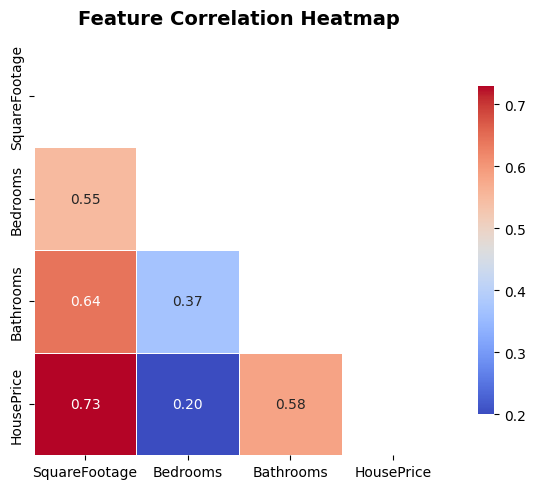

Correlation with HousePrice:
SquareFootage   0.73
Bathrooms       0.58
Bedrooms        0.20
Name: HousePrice, dtype: float64


In [124]:
# ── 4.4 : Correlation Heatmap ──
corr = df.corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8},
    ax=ax
)

ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlation with HousePrice:")
print(corr['HousePrice'].drop('HousePrice').sort_values(ascending=False))

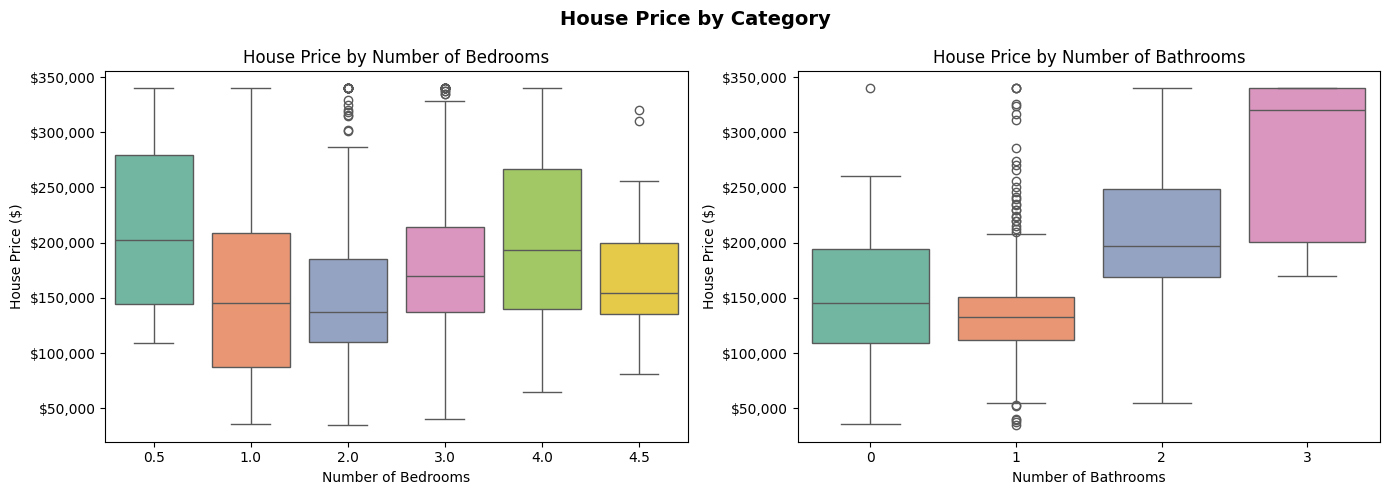

In [125]:
# ── 4.5 : Box plots — Price by Bedrooms & Bathrooms ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('House Price by Category', fontsize=14, fontweight='bold')

palette = sns.color_palette('Set2')

sns.boxplot(data=df, x='Bedrooms', y='HousePrice', palette=palette, ax=axes[0])
axes[0].set_title('House Price by Number of Bedrooms')
axes[0].set_xlabel('Number of Bedrooms')
axes[0].set_ylabel('House Price ($)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.boxplot(data=df, x='Bathrooms', y='HousePrice', palette=palette, ax=axes[1])
axes[1].set_title('House Price by Number of Bathrooms')
axes[1].set_xlabel('Number of Bathrooms')
axes[1].set_ylabel('House Price ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('price_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

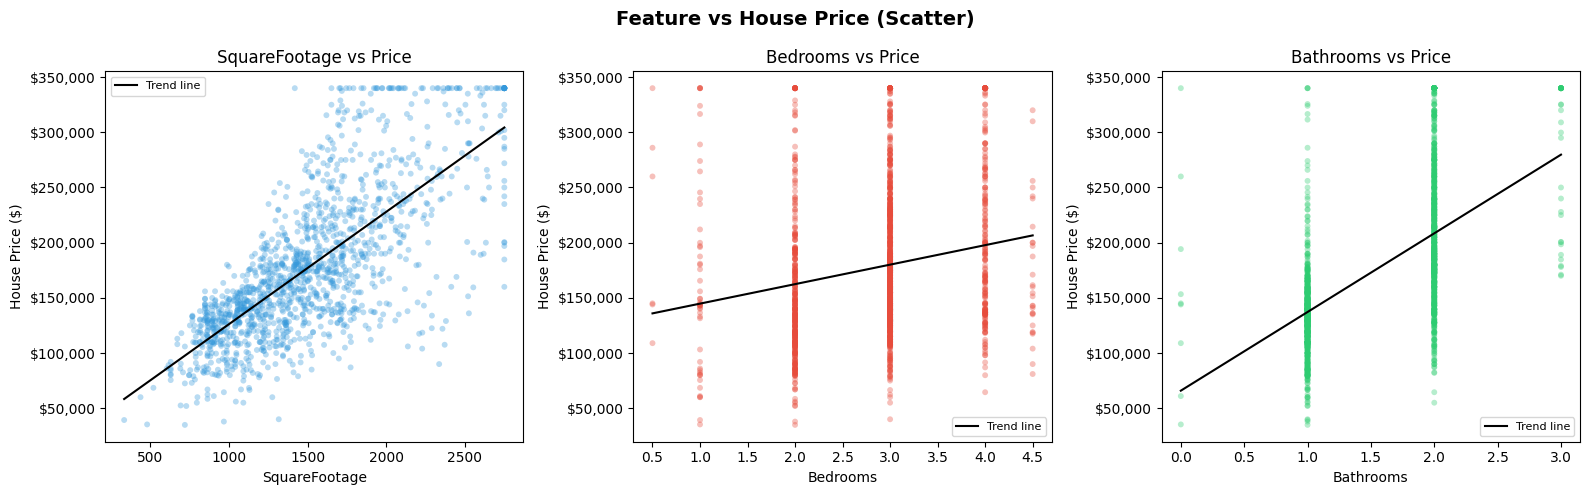

In [126]:
# ── 4.6 : Scatter plots — Features vs HousePrice ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Feature vs House Price (Scatter)', fontsize=14, fontweight='bold')

features = ['SquareFootage', 'Bedrooms', 'Bathrooms']
colors   = ['#3498DB', '#E74C3C', '#2ECC71']

for ax, feat, clr in zip(axes, features, colors):
    ax.scatter(df[feat], df['HousePrice'], alpha=0.35, color=clr, s=18, edgecolors='none')
    # Fit line
    m, b = np.polyfit(df[feat], df['HousePrice'], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, label='Trend line')
    ax.set_xlabel(feat)
    ax.set_ylabel('House Price ($)')
    ax.set_title(f'{feat} vs Price')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('scatter_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Selection <a id="5-feature-selection"></a>

Per the task requirements, we use **exactly three features**:

| Feature | Column | Rationale |
|---|---|---|
| Square Footage | `SquareFootage` | Strongest single predictor of price (largest living area) |
| Number of Bedrooms | `Bedrooms` | Standard measure of house size and demand |
| Number of Bathrooms | `Bathrooms` | Positively correlated with price and living quality |

**Target variable:** `HousePrice`

In [127]:
# ── Feature & Target definition ──
FEATURES = ['SquareFootage', 'Bedrooms', 'Bathrooms']
TARGET   = 'HousePrice'

X = df[FEATURES]
y = df[TARGET]

print("Features (X):")
print(X.head())
print()
print("Target  (y):")
print(y.head().to_frame())
print()
print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")

Features (X):
   SquareFootage  Bedrooms  Bathrooms
0        1710.00      3.00          2
1        1262.00      3.00          2
2        1786.00      3.00          2
3        1717.00      3.00          1
4        2198.00      4.00          2

Target  (y):
   HousePrice
0      208500
1      181500
2      223500
3      140000
4      250000

Feature matrix shape : (1456, 3)
Target vector shape  : (1456,)


## 6. Train-Test Split <a id="6-train-test-split"></a>

We split the dataset into:
- **80% training set** — used to fit the Linear Regression model
- **20% test set** — held out and used only for evaluating model performance

`random_state=42` ensures reproducible results.

In [128]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("═" * 45)
print("  TRAIN-TEST SPLIT SUMMARY")
print("═" * 45)
print(f"  Total samples  : {len(df):,}")
print(f"  Training set   : {len(X_train):,}  ({len(X_train)/len(df)*100:.1f}%)")
print(f"  Test set       : {len(X_test):,}   ({len(X_test)/len(df)*100:.1f}%)")
print()
print(f"  X_train shape  : {X_train.shape}")
print(f"  X_test  shape  : {X_test.shape}")
print(f"  y_train shape  : {y_train.shape}")
print(f"  y_test  shape  : {y_test.shape}")

═════════════════════════════════════════════
  TRAIN-TEST SPLIT SUMMARY
═════════════════════════════════════════════
  Total samples  : 1,456
  Training set   : 1,164  (79.9%)
  Test set       : 292   (20.1%)

  X_train shape  : (1164, 3)
  X_test  shape  : (292, 3)
  y_train shape  : (1164,)
  y_test  shape  : (292,)


## 7. Model Training — Linear Regression <a id="7-model-training"></a>

**Linear Regression** assumes a linear relationship between features and the target:

$$\hat{y} = \beta_0 + \beta_1 \cdot \text{SquareFootage} + \beta_2 \cdot \text{Bedrooms} + \beta_3 \cdot \text{Bathrooms}$$

The model minimises the **Residual Sum of Squares (RSS)** using Ordinary Least Squares (OLS):

$$\text{RSS} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

We also inspect the learned **coefficients** and **intercept**.

In [129]:
# ── Train the model ──
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Linear Regression model trained successfully!")
print()
print("═" * 50)
print("  MODEL COEFFICIENTS")
print("═" * 50)
print(f"  Intercept (β₀)        : ${model.intercept_:,.2f}")
print()
for feat, coef in zip(FEATURES, model.coef_):
    print(f"  {feat:<20} : ${coef:>10,.4f}")

print()
print("Interpretation:")
print(f"  • Each extra sq ft   adds  ${model.coef_[0]:,.2f} to the predicted price")
print(f"  • Each extra bedroom adds  ${model.coef_[1]:,.2f} to the predicted price")
print(f"  • Each extra bathroom adds ${model.coef_[2]:,.2f} to the predicted price")

✅ Linear Regression model trained successfully!

══════════════════════════════════════════════════
  MODEL COEFFICIENTS
══════════════════════════════════════════════════
  Intercept (β₀)        : $54,098.81

  SquareFootage        : $  107.2128
  Bedrooms             : $-25,528.7443
  Bathrooms            : $22,035.4604

Interpretation:
  • Each extra sq ft   adds  $107.21 to the predicted price
  • Each extra bedroom adds  $-25,528.74 to the predicted price
  • Each extra bathroom adds $22,035.46 to the predicted price


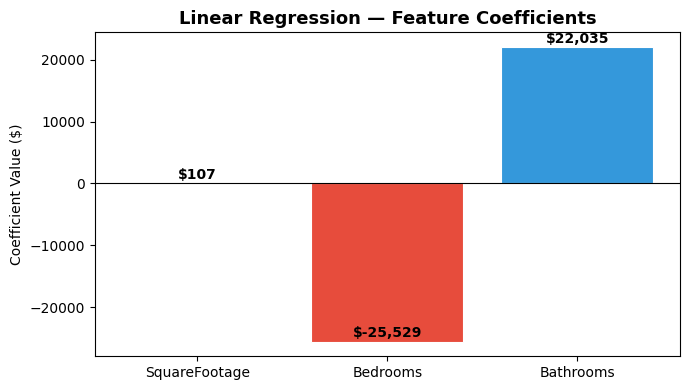

In [130]:
# ── Coefficient bar chart ──
fig, ax = plt.subplots(figsize=(7, 4))
colors_bar = ['#3498DB' if c > 0 else '#E74C3C' for c in model.coef_]
bars = ax.bar(FEATURES, model.coef_, color=colors_bar, edgecolor='white', linewidth=0.8)
ax.set_title('Linear Regression — Feature Coefficients', fontsize=13, fontweight='bold')
ax.set_ylabel('Coefficient Value ($)')
ax.axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, model.coef_):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Predictions <a id="8-predictions"></a>

We generate predictions on the **held-out test set** and compare them with the actual prices. We also demonstrate a **custom prediction** for a house with specified characteristics.

In [131]:
# ── Predictions on test set ──
y_pred = model.predict(X_test)

# Build comparison dataframe
results_df = X_test.copy().reset_index(drop=True)
results_df['Actual_Price']    = y_test.reset_index(drop=True)
results_df['Predicted_Price'] = np.round(y_pred, 2)
results_df['Error']           = results_df['Actual_Price'] - results_df['Predicted_Price']
results_df['Abs_Error']       = results_df['Error'].abs()
results_df['Error_%']         = (results_df['Abs_Error'] / results_df['Actual_Price'] * 100).round(2)

print("Sample Predictions (first 15 rows):")
print()
print(results_df.head(15).to_string(index=False))

Sample Predictions (first 15 rows):

 SquareFootage  Bedrooms  Bathrooms  Actual_Price  Predicted_Price     Error  Abs_Error  Error_%
        899.00      3.00          1        130000         95932.33  34067.67   34067.67    26.21
       1337.00      2.00          2        181000        190455.74  -9455.74    9455.74     5.22
       1478.00      2.00          2        222000        205572.74  16427.26   16427.26     7.40
        930.00      2.00          1         84900        124784.67 -39884.67   39884.67    46.98
       1620.00      2.00          2        315500        220796.95  94703.05   94703.05    30.02
        630.00      1.00          1         75500        118149.58 -42649.58   42649.58    56.49
       1248.00      2.00          2        167240        180913.80 -13673.80   13673.80     8.18
       1221.00      4.00          1        104900        104926.10    -26.10      26.10     0.02
       1352.00      4.00          1        158000        118970.98  39029.02   39029.02   

In [132]:
# ── Custom house prediction ──
print("═" * 50)
print("  CUSTOM HOUSE PRICE PREDICTION")
print("═" * 50)

custom_houses = pd.DataFrame({
    'SquareFootage': [1500, 2500, 3500],
    'Bedrooms'     : [3,    4,    5   ],
    'Bathrooms'    : [2,    3,    4   ],
})

custom_prices = model.predict(custom_houses)

print()
for i, (_, row) in enumerate(custom_houses.iterrows()):
    print(f"  House {i+1}: {int(row.SquareFootage):,} sqft | "
          f"{int(row.Bedrooms)} bed | {int(row.Bathrooms)} bath  →  "
          f"Predicted Price: ${custom_prices[i]:,.0f}")

══════════════════════════════════════════════════
  CUSTOM HOUSE PRICE PREDICTION
══════════════════════════════════════════════════

  House 1: 1,500 sqft | 3 bed | 2 bath  →  Predicted Price: $182,403
  House 2: 2,500 sqft | 4 bed | 3 bath  →  Predicted Price: $286,122
  House 3: 3,500 sqft | 5 bed | 4 bath  →  Predicted Price: $389,842


## 9. Model Evaluation <a id="9-model-evaluation"></a>

We evaluate the model using four standard regression metrics:

| Metric | Formula | Interpretation |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Average absolute error in dollar terms |
| **MSE** | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | Penalises large errors more heavily |
| **RMSE** | $\sqrt{\text{MSE}}$ | Same unit as target; most interpretable |
| **R² Score** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Proportion of variance explained (0–1, higher = better) |

In [133]:
# ── Compute metrics ──
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

# Training score (to check for overfitting)
y_train_pred = model.predict(X_train)
r2_train     = r2_score(y_train, y_train_pred)

print("╔" + "═" * 48 + "╗")
print("║  MODEL EVALUATION RESULTS                      ║")
print("╠" + "═" * 48 + "╣")
print(f"║  MAE         : ${mae:>30,.2f}  ║")
print(f"║  MSE         : ${mse:>30,.2f}  ║")
print(f"║  RMSE        : ${rmse:>30,.2f}  ║")
print(f"║  R² (Test)   : {r2:>33.4f}  ║")
print(f"║  R² (Train)  : {r2_train:>33.4f}  ║")
print("╚" + "═" * 48 + "╝")
print()
print("Interpretation:")
print(f"  • The model explains {r2*100:.1f}% of the variance in house prices.")
print(f"  • On average, predictions are off by ${mae:,.0f} (MAE).")
print(f"  • RMSE of ${rmse:,.0f} gives a penalty-weighted error estimate.")
if abs(r2_train - r2) < 0.05:
    print("  • Train vs Test R² difference < 0.05 → No significant overfitting.")
else:
    print(f"  • Train R²={r2_train:.4f} vs Test R²={r2:.4f} → Moderate overfitting detected.")

╔════════════════════════════════════════════════╗
║  MODEL EVALUATION RESULTS                      ║
╠════════════════════════════════════════════════╣
║  MAE         : $                     31,425.87  ║
║  MSE         : $              1,698,118,281.33  ║
║  RMSE        : $                     41,208.23  ║
║  R² (Test)   :                            0.6491  ║
║  R² (Train)  :                            0.6035  ║
╚════════════════════════════════════════════════╝

Interpretation:
  • The model explains 64.9% of the variance in house prices.
  • On average, predictions are off by $31,426 (MAE).
  • RMSE of $41,208 gives a penalty-weighted error estimate.
  • Train vs Test R² difference < 0.05 → No significant overfitting.


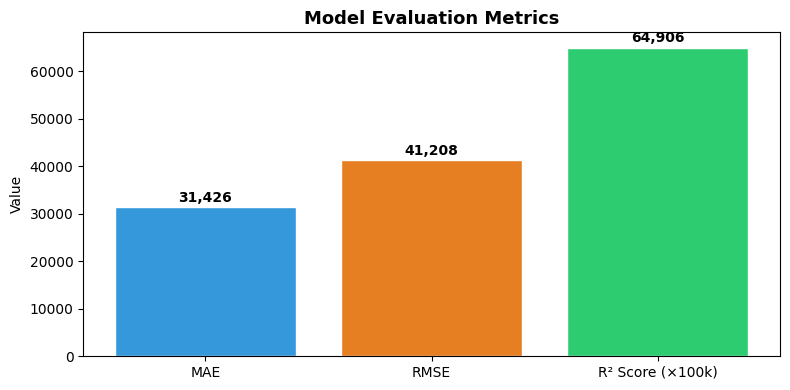

In [134]:
# ── Metrics bar chart ──
metrics_labels = ['MAE', 'RMSE', 'R² Score (×100k)']
metrics_vals   = [mae, rmse, r2 * 100_000]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(metrics_labels, metrics_vals,
              color=['#3498DB', '#E67E22', '#2ECC71'], edgecolor='white')
ax.set_title('Model Evaluation Metrics', fontsize=13, fontweight='bold')
ax.set_ylabel('Value')
for bar, val in zip(bars, metrics_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Visualizations <a id="10-visualizations"></a>

Four key diagnostic plots:
1. **Correlation Heatmap** ← already produced in EDA
2. **House Price Distribution** ← already produced in EDA
3. **Actual vs Predicted Plot** — ideal model lies on the diagonal (y = x line)
4. **Residual Plot** — residuals should be randomly scattered around zero

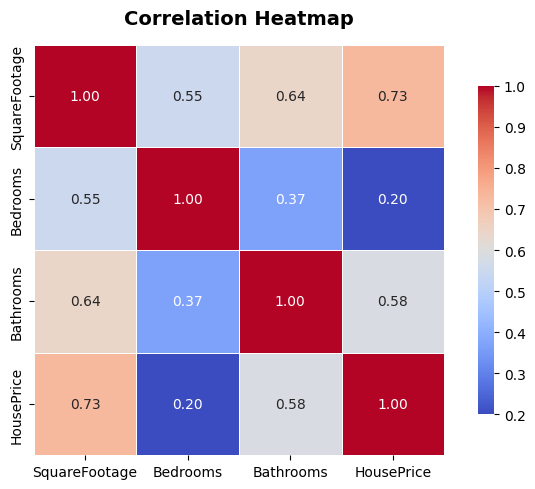

In [135]:
# ── 10.1 Re-display Correlation Heatmap ──
corr = df.corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('viz_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

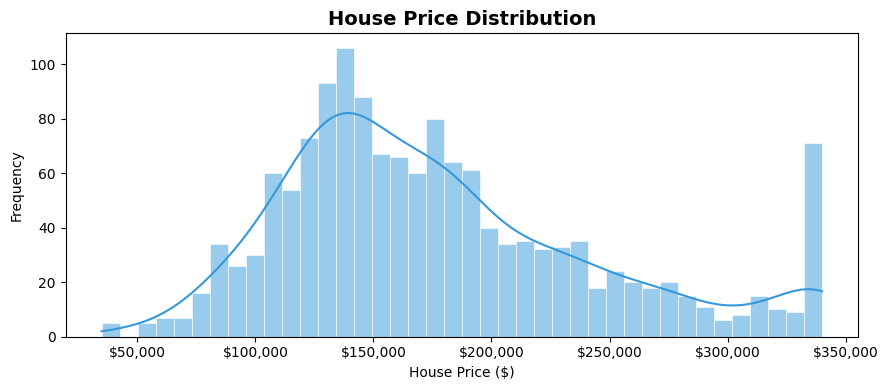

In [136]:
# ── 10.2 Re-display House Price Distribution ──
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df['HousePrice'], bins=40, kde=True, color='#3498DB',
             edgecolor='white', linewidth=0.4, ax=ax)
ax.set_title('House Price Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('House Price ($)')
ax.set_ylabel('Frequency')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('viz_price_dist.png', dpi=150, bbox_inches='tight')
plt.show()

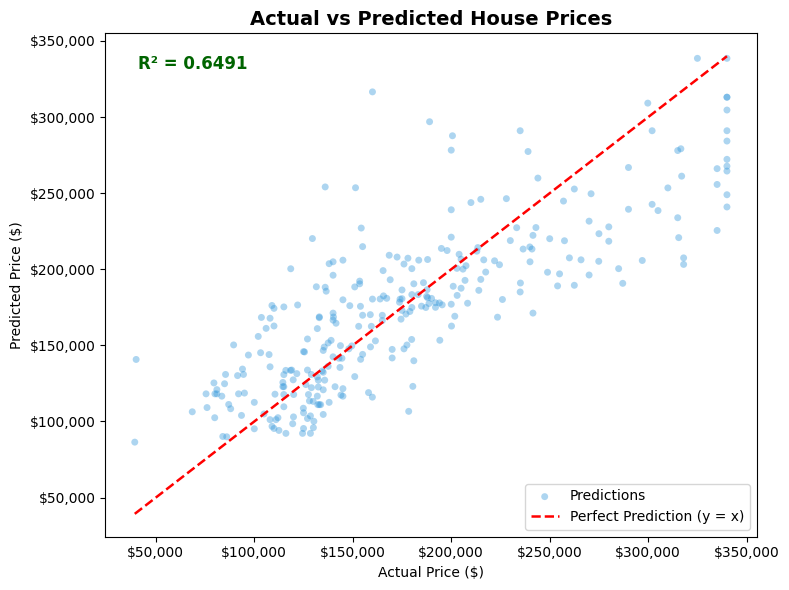

In [137]:
# ── 10.3 Actual vs Predicted Plot ──
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test, y_pred, alpha=0.4, color='#3498DB', s=25, edgecolors='none',
           label='Predictions')

# Perfect prediction line
lim_min = min(y_test.min(), y_pred.min())
lim_max = max(y_test.max(), y_pred.max())
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.8,
        label='Perfect Prediction (y = x)')

ax.set_title('Actual vs Predicted House Prices', fontsize=14, fontweight='bold')
ax.set_xlabel('Actual Price ($)')
ax.set_ylabel('Predicted Price ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
ax.text(0.05, 0.93, f'R² = {r2:.4f}', transform=ax.transAxes,
        fontsize=12, color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.savefig('viz_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

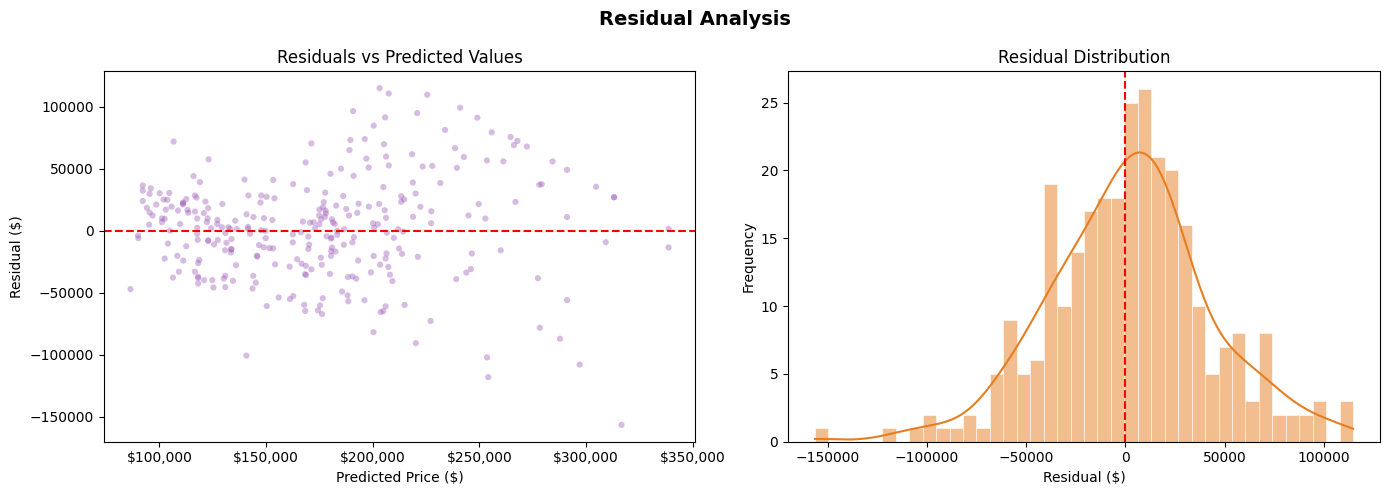

Residual mean  : $1,924.72  (should be near 0)
Residual std   : $41,163.26


In [138]:
# ── 10.4 Residual Plot ──
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Residual Analysis', fontsize=14, fontweight='bold')

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.4, color='#9B59B6', s=20, edgecolors='none')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuals vs Predicted Values')
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Residual ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Residual Distribution
sns.histplot(residuals, bins=40, kde=True, color='#E67E22',
             edgecolor='white', linewidth=0.4, ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('viz_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Residual mean  : ${np.mean(residuals):,.2f}  (should be near 0)")
print(f"Residual std   : ${np.std(residuals):,.2f}")

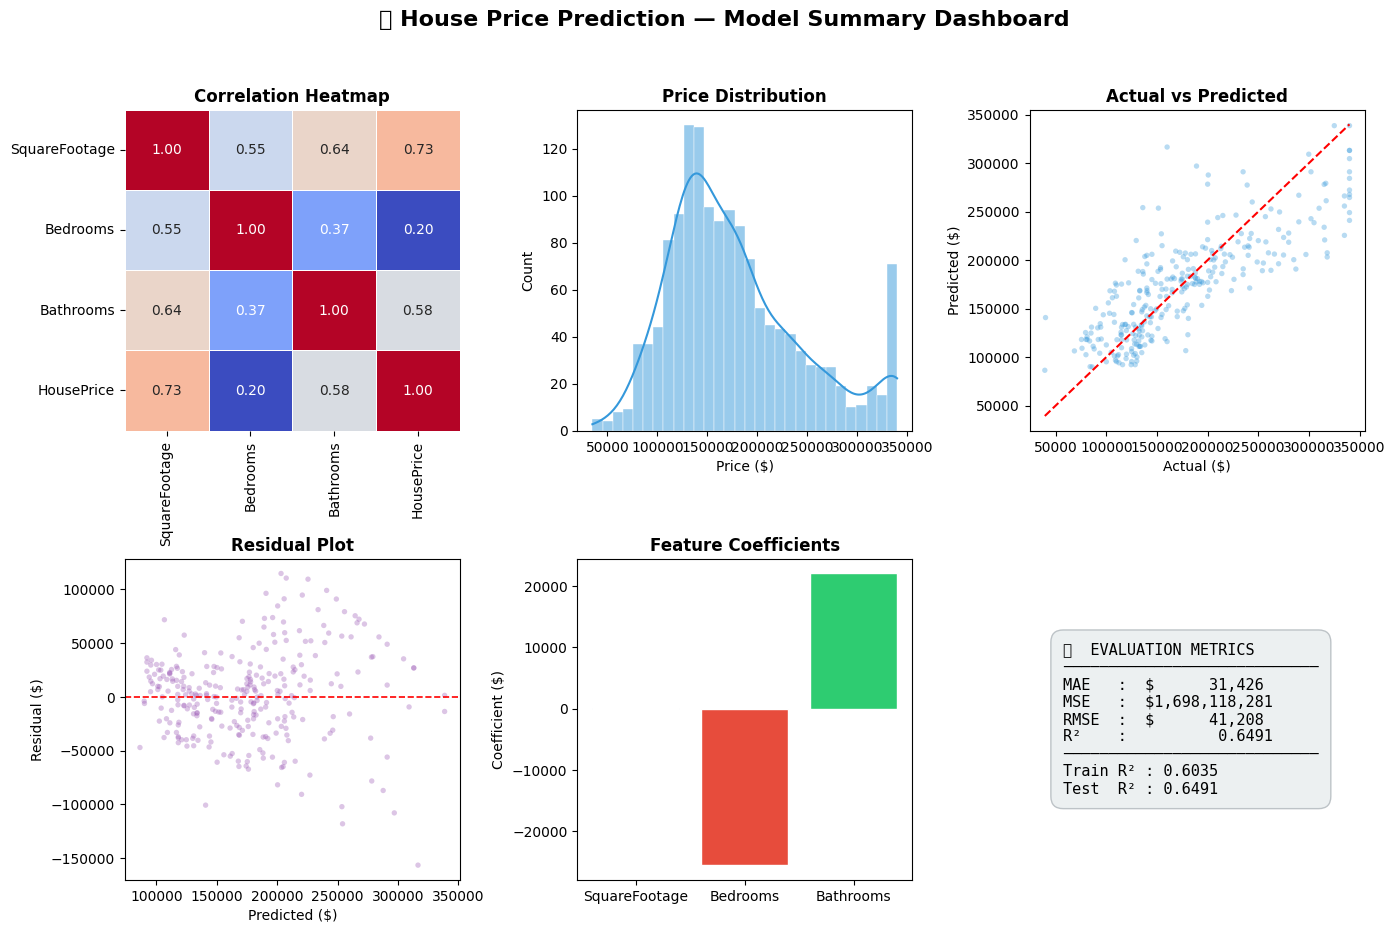

✅ Dashboard saved as 'dashboard.png'


In [139]:
# ── Final Model Summary Dashboard ──
fig = plt.figure(figsize=(16, 10))
fig.suptitle('🏠 House Price Prediction — Model Summary Dashboard',
             fontsize=16, fontweight='bold', y=0.98)

gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# 1. Heatmap
ax1 = fig.add_subplot(gs[0, 0])
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar=False, ax=ax1)
ax1.set_title('Correlation Heatmap', fontweight='bold')

# 2. Price Distribution
ax2 = fig.add_subplot(gs[0, 1])
sns.histplot(df['HousePrice'], bins=30, kde=True, color='#3498DB',
             edgecolor='white', linewidth=0.3, ax=ax2)
ax2.set_title('Price Distribution', fontweight='bold')
ax2.set_xlabel('Price ($)')

# 3. Actual vs Predicted
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(y_test, y_pred, alpha=0.35, color='#3498DB', s=15, edgecolors='none')
ax3.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', linewidth=1.5)
ax3.set_title('Actual vs Predicted', fontweight='bold')
ax3.set_xlabel('Actual ($)')
ax3.set_ylabel('Predicted ($)')

# 4. Residuals
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(y_pred, residuals, alpha=0.35, color='#9B59B6', s=15, edgecolors='none')
ax4.axhline(0, color='red', linestyle='--', linewidth=1.2)
ax4.set_title('Residual Plot', fontweight='bold')
ax4.set_xlabel('Predicted ($)')
ax4.set_ylabel('Residual ($)')

# 5. Coefficients
ax5 = fig.add_subplot(gs[1, 1])
ax5.bar(FEATURES, model.coef_, color=['#3498DB', '#E74C3C', '#2ECC71'], edgecolor='white')
ax5.set_title('Feature Coefficients', fontweight='bold')
ax5.set_ylabel('Coefficient ($)')

# 6. Metrics text box
ax6 = fig.add_subplot(gs[1, 2])
ax6.axis('off')
metrics_text = (
    f"📊  EVALUATION METRICS\n"
    f"{'─'*28}\n"
    f"MAE   :  ${mae:>12,.0f}\n"
    f"MSE   :  ${mse:>12,.0f}\n"
    f"RMSE  :  ${rmse:>12,.0f}\n"
    f"R²    :  {r2:>14.4f}\n"
    f"{'─'*28}\n"
    f"Train R² : {r2_train:.4f}\n"
    f"Test  R² : {r2:.4f}"
)
ax6.text(0.1, 0.5, metrics_text, transform=ax6.transAxes,
         fontsize=11, verticalalignment='center', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='#ECF0F1', edgecolor='#BDC3C7'))

plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved as 'dashboard.png'")

## 11. Interview Questions and Answers <a id="11-interview-qa"></a>

---

### Q1. What is Linear Regression and how does it work?
**A:** Linear Regression is a supervised machine learning algorithm that models the relationship between one or more input features and a continuous target variable by fitting a linear equation to the observed data. It minimises the **Residual Sum of Squares (RSS)** using Ordinary Least Squares (OLS) to find the best-fit line (or hyperplane in multiple dimensions).

---

### Q2. What are the key assumptions of Linear Regression?
**A:**
1. **Linearity** — relationship between X and y is linear
2. **Independence** — observations are independent of each other
3. **Homoscedasticity** — constant variance of residuals
4. **Normality of errors** — residuals are normally distributed
5. **No multicollinearity** — features are not highly correlated with each other

---

### Q3. What is the difference between MAE, MSE, and RMSE?
**A:**
- **MAE** (Mean Absolute Error) — average of absolute differences; same unit as target; robust to outliers
- **MSE** (Mean Squared Error) — average of squared differences; penalises large errors more; harder to interpret
- **RMSE** (Root Mean Squared Error) — square root of MSE; same unit as target; most commonly reported

---

### Q4. What does R² Score represent? Can it be negative?
**A:** R² (coefficient of determination) measures the **proportion of variance in the target variable explained by the model**. It ranges from 0 to 1 (100%), where 1 = perfect fit. **Yes**, R² can be negative if the model performs worse than a horizontal mean line, which indicates the model is fundamentally inappropriate for the data.

---

### Q5. How do you handle outliers in regression?
**A:** Common strategies include: (1) **IQR-based capping/clipping**, (2) **log transformation** of skewed features, (3) **Winsorization** (replacing extremes with percentile values), (4) using **robust regression** (e.g., Huber loss), and (5) **removing** clear data-entry errors after investigation.

---

### Q6. What is the difference between overfitting and underfitting?
**A:**
- **Overfitting** — model learns noise in training data; high train R², low test R²; low bias, high variance
- **Underfitting** — model is too simple; low R² on both train and test; high bias, low variance
- **Solution** — cross-validation, regularisation (Ridge/Lasso), feature engineering

---

### Q7. Why did we use the median instead of mean for imputation?
**A:** The **median is robust to outliers**, whereas the mean is heavily influenced by extreme values. In house price datasets, extreme values (e.g., a 10,000 sqft mansion) can skew the mean significantly, making median imputation the safer choice.

---

### Q8. What is multicollinearity and how does it affect Linear Regression?
**A:** Multicollinearity occurs when two or more features are highly correlated with each other. It makes coefficient estimates **unstable and unreliable**, inflating their standard errors, and makes it hard to determine the individual effect of each feature. It can be detected using **VIF (Variance Inflation Factor)** and addressed by removing correlated features or using **Ridge Regression**.

---

### Q9. What is regularisation and when should you use Ridge or Lasso?
**A:** Regularisation adds a **penalty term** to the loss function to prevent overfitting:
- **Ridge (L2)** — shrinks coefficients toward zero but doesn't eliminate them; good when all features contribute
- **Lasso (L1)** — can shrink coefficients to exactly zero; performs automatic feature selection
- **ElasticNet** — combination of both

---

### Q10. How would you improve this model further?
**A:**
1. **Add more features** — neighbourhood, year built, lot area, garage size
2. **Feature engineering** — create interaction terms (e.g., sqft × bathrooms)
3. **Log-transform** the target (HousePrice is right-skewed)
4. **Try polynomial regression** to capture non-linear relationships
5. **Try advanced models** — Random Forest, Gradient Boosting (XGBoost, LightGBM)
6. **Cross-validation** — k-fold CV for more reliable evaluation
7. **Hyperparameter tuning** — GridSearchCV / RandomizedSearchCV

---

In [140]:
print("=" * 80)
print("HOUSE PRICE PREDICTION - PROJECT SUMMARY")
print("=" * 80)

print(f"Organisation : SkillCraft Technology")
print(f"Task         : Task 1 - Linear Regression")
print("-" * 80)

print(f"Dataset size : {len(df):,} rows")
print("Features used: SquareFootage, Bedrooms, Bathrooms")
print("Model        : Linear Regression (OLS)")
print("-" * 80)

print(f"MAE      : ${mae:,.0f}")
print(f"MSE      : ${mse:,.0f}")
print(f"RMSE     : ${rmse:,.0f}")
print(f"R² Score : {r2:.4f}")

print("=" * 80)

HOUSE PRICE PREDICTION - PROJECT SUMMARY
Organisation : SkillCraft Technology
Task         : Task 1 - Linear Regression
--------------------------------------------------------------------------------
Dataset size : 1,456 rows
Features used: SquareFootage, Bedrooms, Bathrooms
Model        : Linear Regression (OLS)
--------------------------------------------------------------------------------
MAE      : $31,426
MSE      : $1,698,118,281
RMSE     : $41,208
R² Score : 0.6491
